In [1]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
import pylab as pl
from sklearn.kernel_approximation import RBFSampler
%matplotlib inline

In [2]:
gamma = 1
components = 128
sampler = RBFSampler(n_components=components,gamma=gamma, random_state=1)
x = np.linspace(-5, 5, 100)
X_train = x[:, np.newaxis]
xt = sampler.fit_transform(X_train)
xt = xt / np.linalg.norm(xt, axis=1)[:, np.newaxis]
xt0 = sampler.transform([[2]])
xt0 = xt0 / np.linalg.norm(xt0)
np.linalg.norm(xt, axis=1)
sampler1 = RBFSampler(n_components=components,gamma=gamma*2, random_state=1)
xt1 = sampler1.fit_transform(X_train)
xt10 = sampler1.transform([[2]])

X_test=X_train

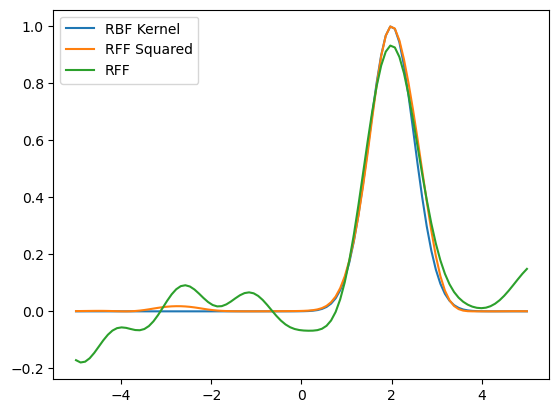

In [3]:
pl.plot(x, rbf_kernel(x[:, np.newaxis],[[2]], gamma=2 ))
pl.plot(x, (xt @ xt0.T) ** 2 )
pl.plot(x, (xt1 @ xt10.T) )

pl.legend(["RBF Kernel", "RFF Squared", "RFF"])

In [4]:
from scipy.integrate import simps

print(simps(rbf_kernel(x[:, np.newaxis], [[0]]).T, x))
print(simps((xt0 @ xt.T) ** 2, x))

[1.77245385]
[1.33207968]


In [13]:
import tensorflow as tf
from demande.models.demande.adaptive_rff import QFeatureMapAdaptRFF, DMRFF, calc_rbf

(10000,)
0.004999499949994852


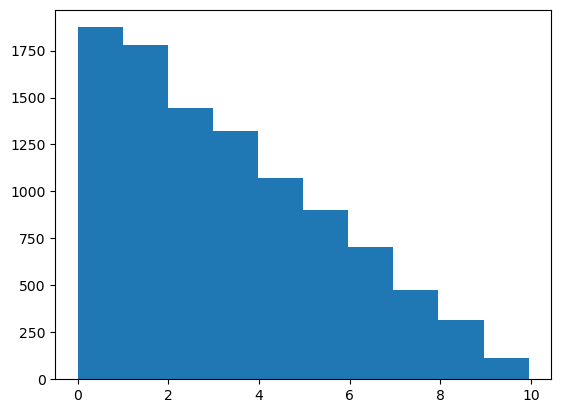

In [14]:
num_samples = 10000
x_aff = np.linspace(-5, 5, 10000)
X_train_aff = x_aff[:, np.newaxis]
X_test_aff = x_aff[:, np.newaxis]
rnd_idx1 = np.random.randint(X_train_aff.shape[0],size=(num_samples, ))
rnd_idx2 = np.random.randint(X_train_aff.shape[0],size=(num_samples, ))
#x_train_rff = [X_train[rnd_idx1], X_train[rnd_idx2]]
x_train_rff = np.concatenate([X_train_aff[rnd_idx1][:, np.newaxis, ...],
                          X_train_aff[rnd_idx2][:, np.newaxis, ...]],
                         axis=1)
dists = np.linalg.norm(x_train_rff[:, 0, ...] - x_train_rff[:, 1, ...], axis=1)
print(dists.shape)
pl.hist(dists)
print(np.quantile(dists, 0.001))
rnd_idx1 = np.random.randint(X_test_aff.shape[0],size=(num_samples, ))
rnd_idx2 = np.random.randint(X_test_aff.shape[0],size=(num_samples, ))
#x_test_rff = [X_test[rnd_idx1], X_test[rnd_idx2]]
x_test_rff = np.concatenate([X_test_aff[rnd_idx1][:, np.newaxis, ...],
                          X_test_aff[rnd_idx2][:, np.newaxis, ...]],
                         axis=1)

In [15]:
def gauss_kernel_arr(x, y, gamma):
    return np.exp(-gamma * np.linalg.norm(x - y, axis=2) ** 2)

In [16]:
x_train_rff=x_train_rff[:,:,np.newaxis]
x_test_rff=x_test_rff[:,:,np.newaxis]

In [17]:
n_rffs = 1000
gamma=2
dimension=1
print(f'Gamma: {gamma}')


y_train_rff = gauss_kernel_arr(x_train_rff[:, 0, ...], x_train_rff[:, 1, ...], gamma=gamma)
y_test_rff = gauss_kernel_arr(x_test_rff[:, 0, ...], x_test_rff[:, 1, ...], gamma=gamma)
dmrff = DMRFF(dim_x=dimension, num_rff=n_rffs, gamma=gamma, random_state=0)
dm_rbf = calc_rbf(dmrff, x_test_rff[:, 1, ...], x_test_rff[:, 1, ...])

opt = tf.keras.optimizers.Adam(learning_rate=0.01)

dmrff.compile(optimizer=opt, loss='mae')
dmrff.evaluate(x_test_rff, y_test_rff, batch_size=256)

Gamma: 2
build: dim 1000
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
40/40 [==============================] - 0s 1ms/step - loss: 0.0784


0.0783616453409195

Mean: -0.09051341563463211
Std: 1.9740663766860962
Gamma: 2.0


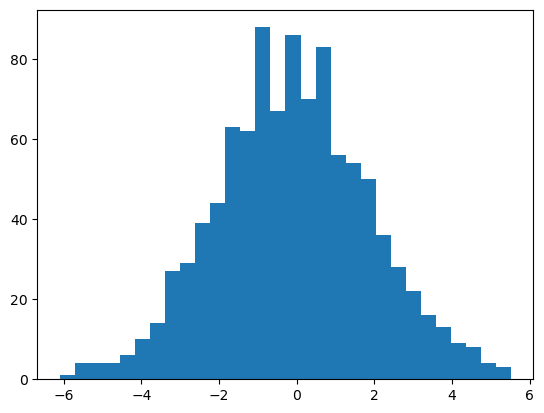

In [18]:
print(f'Mean: {np.mean(dmrff.rff_layer.rff_weights)}')
print(f'Std: {np.std(dmrff.rff_layer.rff_weights)}')
print(f'Gamma: {dmrff.rff_layer.gamma_val.numpy()}')
pl.hist(dmrff.rff_layer.rff_weights.numpy().flatten(), bins=30);

In [19]:
dmrff.fit(x_train_rff, y_train_rff, validation_split=0.1, epochs=1000, batch_size=2048)

Epoch 1/1000


call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
5/5 [==============================] - 0s 37ms/step - loss: 0.0709 - val_loss: 0.0564
Epoch 2/1000
5/5 [==============================] - 0s 35ms/step - loss: 0.0594 - val_loss: 0.0506
Epoch 3/1000
5/5 [==============================] - 0s 35ms/step - loss: 0.0541 - val_loss: 0.0472
Epoch 4/1000
5/5 [==============================] - 0s 33ms/step - loss: 0.0511 - val_loss: 0.0445
Epoch 5/1000
5/5 [==============================] - 0s 33ms/step - loss: 0.0486 - val_loss: 0.0426
Epoch 6/1000
5/5 [==============================] - 0s 31ms/step - loss: 0.0469 - val_loss: 0.0413
Epoch 7/1000
5/5 [==============================] - 0s 31ms/step - loss: 0.0454 - val_loss: 0.0401
Epoch 8/1000
5/5 [==============================] - 0s 32ms/step - loss: 0.0442 - val_loss: 0.0389
Epoch 9/1000
5/5 [===========

call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
40/40 [==============================] - 0s 947us/step - loss: 0.0059


0.005906934384256601

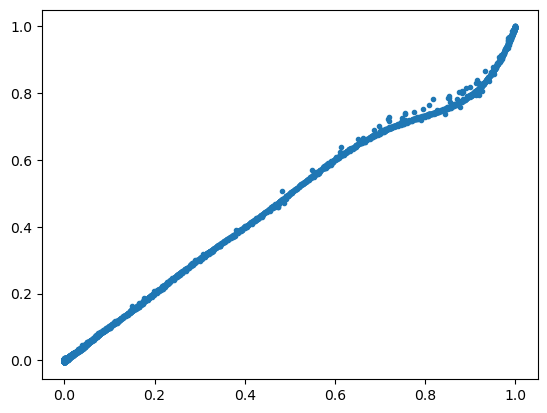

In [20]:
dm_rbf = calc_rbf(dmrff, x_test_rff[:, 0, ...], x_test_rff[:, 1, ...])
pl.plot(y_test_rff, dm_rbf, '.')
dmrff.evaluate(x_test_rff, y_test_rff, batch_size=256)

Mean: -0.061054229736328125
Std: 1.9418935775756836
Gamma: 2.0


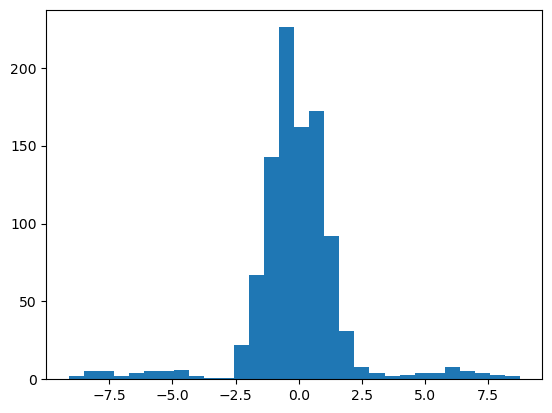

In [21]:
print(f'Mean: {np.mean(dmrff.rff_layer.rff_weights)}')
print(f'Std: {np.std(dmrff.rff_layer.rff_weights)}')
print(f'Gamma: {dmrff.rff_layer.gamma_val.numpy()}')
pl.hist(dmrff.rff_layer.rff_weights.numpy().flatten(), bins=30);


In [ ]:
#dmrff.rff_layer([[1.1 for x in np.arange(10)]])

In [27]:
arr1 = dmrff.rff_layer(X_train).numpy()
arr10 = dmrff.rff_layer(np.array([[2.]])).numpy()

call: inputs (100, 1) rff_weights (1, 1000)
call: inputs (1, 1) rff_weights (1, 1000)


/tmp/ipykernel_182375/252315142.py:5: RuntimeWarning: invalid value encountered in power
  pl.plot(x, (arr1 @ arr10.T) **2 ** (1/2), '--', alpha=1, )


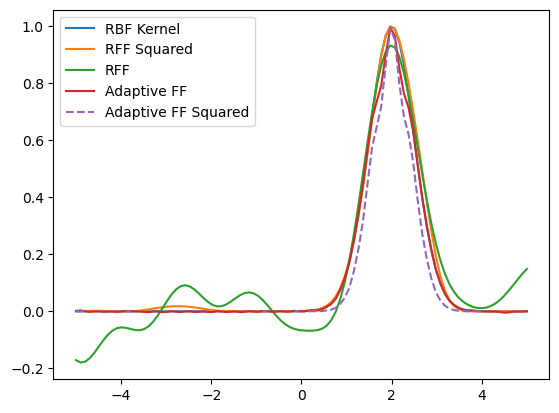

In [28]:
pl.plot(x, rbf_kernel(x[:, np.newaxis],[[2]], gamma=2 ))
pl.plot(x, (xt @ xt0.T) ** 2 )
pl.plot(x, (xt1 @ xt10.T) )
pl.plot(x, (arr1 @ arr10.T) )
pl.plot(x, (arr1 @ arr10.T) **2 ** (1/2), '--', alpha=1, )

pl.legend(["RBF Kernel", "RFF Squared", "RFF",  "Adaptive FF","Adaptive FF Squared"])

In [34]:
results = {}

In [35]:
dimensions = [32,64,128,256,512]
gamma = 1
x = np.linspace(-5, 5, 100)
kernel = rbf_kernel(x[:, np.newaxis],[[2]], gamma=2 )

results['RFF squared'] = []
results['RFF'] = []

for dimension in dimensions:
  sampler = RBFSampler(n_components=dimension,gamma=gamma, random_state=2)
  X_train = x[:, np.newaxis]
  xt = sampler.fit_transform(X_train)
  xt = xt / np.linalg.norm(xt, axis=1)[:, np.newaxis]
  xt0 = sampler.transform(np.array([[2,]]))
  xt0 = xt0 / np.linalg.norm(xt0)
  np.linalg.norm(xt, axis=1)
  sampler1 = RBFSampler(n_components=dimension,gamma=gamma*2, random_state=2)
  xt1 = sampler1.fit_transform(X_train)
  xt10 = sampler1.transform(np.array([[2,]]))

  X_test=X_train
  results["RFF squared"].append((xt @ xt0.T) **2)
  results["RFF"].append(xt1 @ xt10.T)

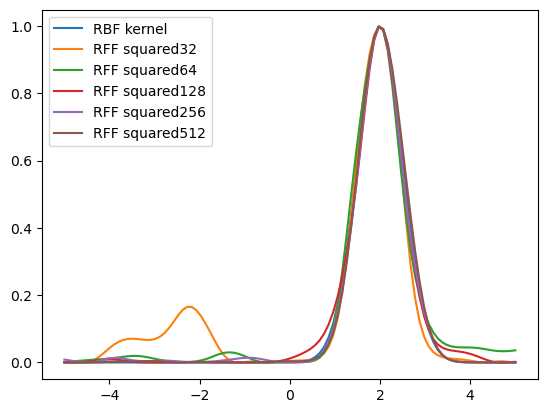

In [39]:
#pl.figure(figsize=(5,10))
pl.plot(x, rbf_kernel(x[:, np.newaxis], np.array([[2]]), gamma=2 ), label="RBF kernel")
for i, dimension in enumerate(dimensions):
  pl.plot(x, results["RFF squared"][i], label= f"RFF squared{dimension}")

pl.legend(loc='upper left')

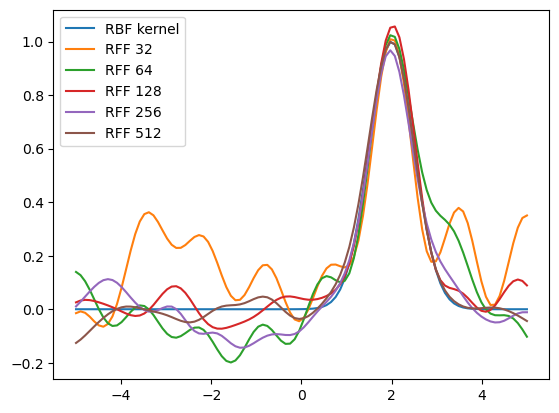

In [ ]:
#pl.figure(figsize=(10,10))
pl.plot(x, rbf_kernel(x[:, np.newaxis],[[2]], gamma=2 ), label="RBF kernel")
for i, dimension in enumerate(dimensions):
  pl.plot(x, results["RFF"][i], label= f"RFF {dimension}")

pl.legend(loc='upper left')

In [42]:
n_rffs = 1000
gamma=1
dimension=1
epochs = 300
batch_size=1024
print(f'Gamma: {gamma}')


y_train_rff = gauss_kernel_arr(x_train_rff[:, 0, ...], x_train_rff[:, 1, ...], gamma=gamma*2)
y_test_rff = gauss_kernel_arr(x_test_rff[:, 0, ...], x_test_rff[:, 1, ...], gamma=gamma*2)
dmrff = DMRFF(dim_x=dimension, num_rff=n_rffs, gamma=gamma, random_state=0)

opt = tf.keras.optimizers.Adam(learning_rate=0.01)

dmrff.compile(optimizer=opt, loss='mse')
dmrff.evaluate(x_test_rff, y_test_rff, batch_size=batch_size)

dmrff.fit(x_train_rff, y_train_rff, validation_split=0.1, epochs=epochs, batch_size=batch_size)

arr0 = dmrff.rff_layer(X_train).numpy()
arr00 = dmrff.rff_layer(np.array([[2.]])).numpy()



Gamma: 1
build: dim 1000
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
10/10 [==============================] - 0s 4ms/step - loss: 0.0011
Epoch 1/300
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
call: inputs (None, 1, 1) rff_weights (1, 1000)
9/9 [==============================] - 0s 16ms/step - loss: 3.4965e-04 - val_loss: 9.3117e-05
Epoch 2/300
9/9 [==============================] - 0s 15ms/step - loss: 8.2650e-05 - val_loss: 5.7243e-05
Epoch 3/300
9/9 [==============================] - 0s 16ms/step - loss: 3.0651e-05 - val_loss: 1.9545e-05
Epoch 4/300
9/9 [==============================] - 0s 17ms/step - loss: 1.6715e-05 - val_loss: 1.0240e-05
Epoch 5/300
9/9 [==============================] - 0s 15ms/step - loss: 6.0317e-06 - val_loss: 5.01

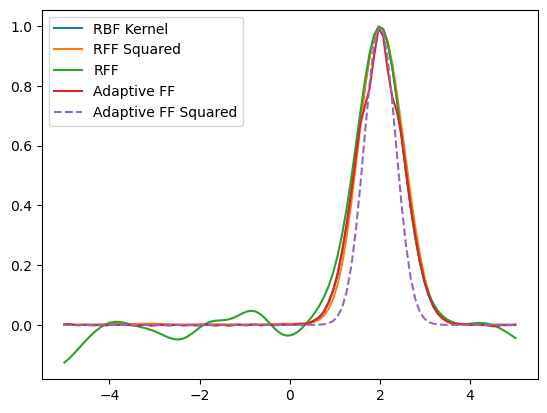

In [43]:
pl.plot(x, rbf_kernel(x[:, np.newaxis],[[2]], gamma=2 ))
pl.plot(x, (xt @ xt0.T) ** 2 )
pl.plot(x, (xt1 @ xt10.T) )
pl.plot(x, (arr1 @ arr10.T) )
pl.plot(x, (arr0 @ arr00.T) **2, '--', alpha=1, )

pl.legend(["RBF Kernel", "RFF Squared", "RFF",  "Adaptive FF","Adaptive FF Squared"])

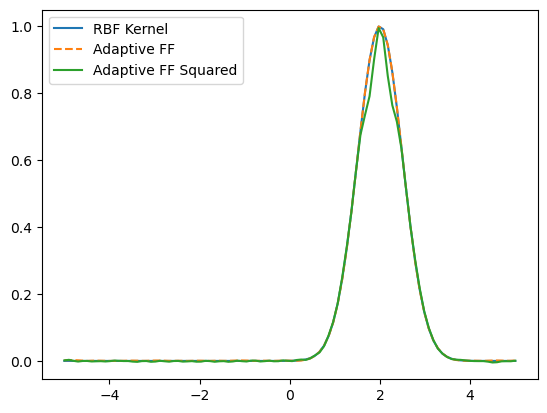

In [44]:
pl.plot(x, rbf_kernel(x[:, np.newaxis],[[2]], gamma=2 ))
pl.plot(x, ((arr0 @ arr00.T) **2) **(1/2), '--', alpha=1, )
pl.plot(x, (arr1 @ arr10.T) )

pl.legend(["RBF Kernel", "Adaptive FF","Adaptive FF Squared"])

In [45]:
arr0.shape

(100, 1000)

In [47]:
epochs = 100
gamma=1
dimension=1
batch_size=2048
print(f'Gamma: {gamma}')
results['Adaptive RFF squared'] = []
results['Adaptive RFF'] = []
polinomial_decay = tf.keras.optimizers.schedules.PolynomialDecay(0.05, \
      500, 0.0001, power=1)
opt = tf.keras.optimizers.Adam(learning_rate=0.01)  # optimizer


for n_rffs in dimensions:


  y_train_rff = gauss_kernel_arr(x_train_rff[:, 0, ...], x_train_rff[:, 1, ...], gamma=gamma*2)
  y_test_rff = gauss_kernel_arr(x_test_rff[:, 0, ...], x_test_rff[:, 1, ...], gamma=gamma*2)
  dmrff = DMRFF(dim_x=dimension, num_rff=n_rffs, gamma=gamma, random_state=0)


  dmrff.compile(optimizer=opt, loss='mse')
  dmrff.evaluate(x_test_rff, y_test_rff, batch_size=batch_size)

  dmrff.fit(x_train_rff, y_train_rff, validation_split=0.1, epochs=epochs, batch_size=batch_size)

  arr0 = dmrff.rff_layer(X_train).numpy()
  arr00 = dmrff.rff_layer(np.array([[2.]])).numpy()

  results['Adaptive RFF squared'].append(((arr0 @ arr00.T) **2)**(1/2))


  y_train_rff = gauss_kernel_arr(x_train_rff[:, 0, ...], x_train_rff[:, 1, ...], gamma=gamma*2)
  y_test_rff = gauss_kernel_arr(x_test_rff[:, 0, ...], x_test_rff[:, 1, ...], gamma=gamma*2)
  dmrff = DMRFF(dim_x=dimension, num_rff=n_rffs, gamma=gamma*2, random_state=0)


  dmrff.compile(optimizer=opt, loss='mse')
  dmrff.evaluate(x_test_rff, y_test_rff, batch_size=batch_size)

  dmrff.fit(x_train_rff, y_train_rff, validation_split=0.1, epochs=epochs, batch_size=batch_size)

  arr1 = dmrff.rff_layer(X_train).numpy()
  arr10 = dmrff.rff_layer(np.array([[2.]])).numpy()

  results['Adaptive RFF'].append(arr1 @ arr10.T)


Gamma: 1
build: dim 32
call: inputs (None, 1, 1) rff_weights (1, 32)
call: inputs (None, 1, 1) rff_weights (1, 32)
call: inputs (None, 1, 1) rff_weights (1, 32)
call: inputs (None, 1, 1) rff_weights (1, 32)
5/5 [==============================] - 0s 1ms/step - loss: 0.0234
Epoch 1/100
call: inputs (None, 1, 1) rff_weights (1, 32)
call: inputs (None, 1, 1) rff_weights (1, 32)
call: inputs (None, 1, 1) rff_weights (1, 32)
call: inputs (None, 1, 1) rff_weights (1, 32)
5/5 [==============================] - 0s 50ms/step - loss: 0.0203 - val_loss: 0.0143
Epoch 2/100
5/5 [==============================] - 0s 5ms/step - loss: 0.0126 - val_loss: 0.0094
Epoch 3/100
5/5 [==============================] - 0s 5ms/step - loss: 0.0088 - val_loss: 0.0073
Epoch 4/100
5/5 [==============================] - 0s 5ms/step - loss: 0.0069 - val_loss: 0.0060
Epoch 5/100
5/5 [==============================] - 0s 5ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 6/100
5/5 [==============================] - 0s 5ms

In [48]:
len(results)

4

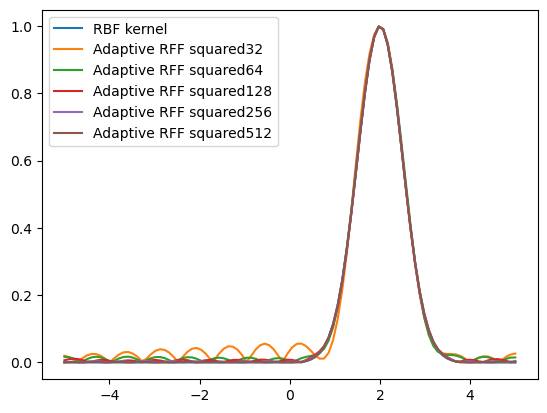

In [50]:
#pl.figure(figsize=(10,10))
pl.plot(x, rbf_kernel(x[:, np.newaxis], np.array([[2]]), gamma=2 ), label="RBF kernel")
for i, dimension in enumerate(dimensions):
  pl.plot(x, results["Adaptive RFF squared"][i], label= f"Adaptive RFF squared{dimension}")

pl.legend(loc='upper left')

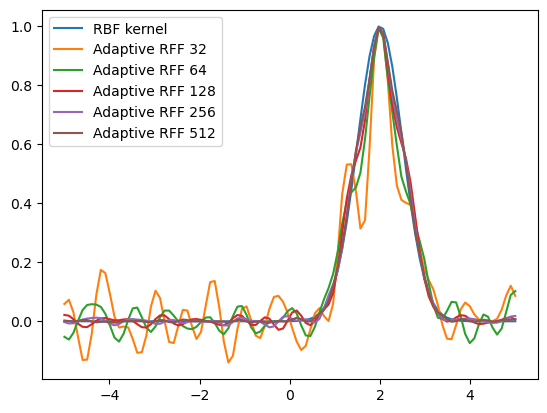

In [52]:
#pl.figure(figsize=(10,10))
rbf_value = rbf_kernel(x[:, np.newaxis],[[2]], gamma=2 )

pl.plot(x, rbf_kernel(x[:, np.newaxis],[[2]], gamma=2 ), label="RBF kernel")
for i, dimension in enumerate(dimensions):
  pl.plot(x, results["Adaptive RFF"][i], label= f"Adaptive RFF {dimension}")

pl.legend(loc='upper left')

In [56]:
np.save(f"../reports/results_gamma={gamma}.npy", results)

In [58]:
results_to_Plot = np.load(f"../reports/results_gamma=1.npy", allow_pickle=True).tolist()